# Practice Notebook: The Power Line Problem -- Optimization with Derivatives

*A personal-practice notebook inspired by the Week 1, Lesson 2 ("Optimization") material in DeepLearning.AI's "Calculus for Machine Learning and Data Science" course.*

This notebook is **not** a copy of the graded assignment -- it's an original set of exercises in the same spirit: take a squared-loss cost function, find its minimum analytically using derivatives (set $f'(x)=0$, confirm with the second derivative test), and apply it to the classic "power line" problem -- finding where to place a connection point so the total squared distance to several houses is as small as possible.

Everything here is solved with **pure calculus** (no gradient descent, no iterative optimizers) -- exactly the analytical approach this lesson focuses on.

**How to use this notebook:**
1. Work through each exercise, filling in the code where you see `### START CODE HERE ###`.
2. Run the test cell right after each exercise -- it will tell you if your implementation is correct.
3. If you get stuck, the **Solutions** section at the very end has full worked implementations. Try not to peek too early!


## Table of Contents
1. Imports
2. Exercise 1 -- The One-House Problem
3. Exercise 2 -- The Two-House Problem
4. Exercise 3 -- The Three-House Problem
5. Exercise 4 (Challenge) -- The General N-House Problem
6. Exercise 5 (Challenge) -- The Weighted Power Line Problem
7. Wrap-up
8. Solutions


## 1. Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 4)


## 2. Exercise 1 -- The One-House Problem

A power line needs to connect to a single house at position $a$ on a straight road. The cost of connecting at position $x$ is the squared distance:

$$D_1(x) = (x - a)^2$$

This is the simplest possible version of the problem -- but it's the building block for everything that follows.

**Your task:** complete `D1(x, a)` below. Write it so it works whether `x` and `a` are plain numbers *or* SymPy symbols -- you'll reuse it symbolically in the test cell.


In [9]:
# GRADED FUNCTION: D1
# D1(x, a) = (x - a)^2

def D1(x, a):
    ### START CODE HERE ### (~ 1 line of code)
    result = (x - a) * (x - a)
    ### END CODE HERE ###
    return result


In [11]:
# Test cell
x_sym, a_sym = sp.symbols('x a')
D1_sym = D1(x_sym, a_sym)
critical_points_1 = sp.solve(sp.diff(D1_sym, x_sym), x_sym)
print("D1(x, a) =", D1_sym)
print("Critical point(s):", critical_points_1)

assert D1(3, 3) == 0, "D1(3, 3) should be 0"
assert D1(5, 3) == 4, "D1(5, 3) should be 4"
assert critical_points_1 == [a_sym], f"Expected the minimizer to be x = a, got {critical_points_1}"
print("Exercise 1 looks correct!")


D1(x, a) = (-a + x)**2
Critical point(s): [a]
Exercise 1 looks correct!


## 3. Exercise 2 -- The Two-House Problem

Now there are two houses, at positions $a$ and $b$. We want the single position $x$ that minimizes the *total* squared distance to both:

$$D_2(x) = (x - a)^2 + (x - b)^2$$

**Your task:** complete `D2(x, a, b)`, then use SymPy to find the critical point in terms of $a$ and $b$, and confirm (by hand, on paper, or just by reasoning about the simplified SymPy expression) that it's the midpoint $\frac{a+b}{2}$.


In [12]:
# GRADED FUNCTION: D2
# D2(x, a, b) = (x - a)^2 + (x - b)^2

def D2(x, a, b):
    ### START CODE HERE ### (~ 1 line of code)
    result = D1(x, a) + D1(x, b)
    ### END CODE HERE ###
    return result


In [13]:
# Test cell
x_sym, a_sym, b_sym = sp.symbols('x a b')
D2_sym = D2(x_sym, a_sym, b_sym)
critical_points_2 = sp.solve(sp.diff(D2_sym, x_sym), x_sym)
print("D2(x, a, b) =", D2_sym)
print("Critical point:", critical_points_2[0])

second_deriv_2 = sp.diff(D2_sym, x_sym, 2)
print("Second derivative:", second_deriv_2, "(always positive -> always a minimum)")

assert sp.simplify(critical_points_2[0] - (a_sym + b_sym)/2) == 0, "Expected the minimizer to be the midpoint (a+b)/2"
assert D2(10, 2, 6) == 80, "D2(10, 2, 6) should be 80"
print("Exercise 2 looks correct!")


D2(x, a, b) = (-a + x)**2 + (-b + x)**2
Critical point: a/2 + b/2
Second derivative: 4 (always positive -> always a minimum)
Exercise 2 looks correct!


## 4. Exercise 3 -- The Three-House Problem

This is the classic version of the problem: three houses on a straight road at positions $x=1$, $x=4$, and $x=9$. Find the position that minimizes the total squared distance:

$$D_3(x) = (x-1)^2 + (x-4)^2 + (x-9)^2$$

**Your task:**
1. Implement `D3(x)`.
2. Find the minimizer analytically with SymPy (differentiate, solve, check the second derivative).
3. Double-check your analytical answer with a brute-force grid search over `x` (no calculus at all -- just evaluate the cost everywhere and see where it's smallest).


In [16]:
# GRADED FUNCTION: D3
# D3(x) = (x-1)^2 + (x-4)^2 + (x-9)^2

def D3(x):
    ### START CODE HERE ### (~ 1 line of code)
    result = D1(x, 1) + D1(x, 4) + D1(x, 9)
    ### END CODE HERE ###
    return result


Critical point: 14/3 = 4.666666666666667
Second derivative: 6 -> minimum since it's positive
Grid search best x: 4.666650000000001


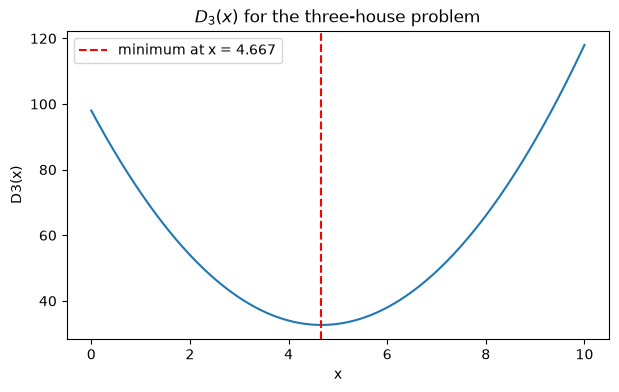

Exercise 3 looks correct!


In [17]:
# Test cell
x_sym = sp.symbols('x')
D3_sym = D3(x_sym)
dD3_sym = sp.diff(D3_sym, x_sym)
critical_point_3 = sp.solve(dD3_sym, x_sym)[0]
second_deriv_3 = sp.diff(D3_sym, x_sym, 2)
print("Critical point:", critical_point_3, "=", float(critical_point_3))
print("Second derivative:", second_deriv_3, "-> minimum since it's positive")

# Brute-force grid search sanity check (no calculus)
grid = np.linspace(0, 10, 200001)
costs = D3(grid)
x_grid_best = grid[np.argmin(costs)]
print("Grid search best x:", x_grid_best)

plt.plot(grid, costs)
plt.axvline(float(critical_point_3), color='red', linestyle='--', label=f"minimum at x = {float(critical_point_3):.3f}")
plt.title("$D_3(x)$ for the three-house problem")
plt.xlabel("x"); plt.ylabel("D3(x)")
plt.legend()
plt.show()

assert np.isclose(float(critical_point_3), 14/3), "Expected the minimizer to be 14/3"
assert np.isclose(x_grid_best, 14/3, atol=1e-3), "Grid search should agree with the analytical answer"
print("Exercise 3 looks correct!")


## 5. Exercise 4 (Challenge) -- The General N-House Problem

What if there are $n$ houses, at arbitrary positions $a_1, a_2, \dots, a_n$? The total squared distance is:

$$D(x) = \sum_{i=1}^{n} (x - a_i)^2$$

**Your task:**
1. First, use SymPy with 4 symbolic house positions to find the general pattern for the minimizer (look at the simplified result -- what familiar quantity is it?).
2. Then implement `total_squared_distance(x, houses)` and `optimal_position(houses)` for NumPy arrays of *any* length, based on the pattern you found.
3. Verify your formula against a brute-force grid search for several random sets of houses.


In [25]:
# GRADED CELL: symbolic pattern for n = 4 houses
x_sym, a1, a2, a3, a4 = sp.symbols('x a1 a2 a3 a4')

### START CODE HERE ###
def D4(x, a1, a2, a3, a4):
    return D1(x, a1) + D1(x, a2) + D1(x, a3) + D1(x, a4)
    
D4_sym = D4(x_sym, a1, a2, a3, a4)            # (x-a1)^2 + (x-a2)^2 + (x-a3)^2 + (x-a4)^2
dD3_sym = sp.diff(D3_sym, x_sym)
critical_point_4 = sp.solve(dD3_sym, x_sym)[0]   # solve dD4/dx = 0 for x, take the result
### END CODE HERE ###

print("Minimizer for 4 houses:", sp.simplify(critical_point_4))


Minimizer for 4 houses: 14/3


In [28]:
# GRADED FUNCTIONS: total_squared_distance, optimal_position
def total_squared_distance(x, houses):
    ### START CODE HERE ### (~ 1-2 lines of code)
    houses = np.asarray(houses)
    result = 0
    for house in houses:
        result += D1(x, house) 
    ### END CODE HERE ###
    return result

def optimal_position(houses):
    ### START CODE HERE ### (~ 1 line of code)
    result = np.mean(houses)
    ### END CODE HERE ###
    return result


In [29]:
# Test cell
rng = np.random.default_rng(0)

for n in [2, 3, 5, 7]:
    houses = rng.uniform(0, 20, size=n)
    x_star = optimal_position(houses)

    grid = np.linspace(x_star - 5, x_star + 5, 200001)
    costs = np.array([total_squared_distance(g, houses) for g in grid])
    x_grid_best = grid[np.argmin(costs)]

    assert np.isclose(x_star, x_grid_best, atol=1e-2), f"For n={n}, formula gave {x_star}, grid search gave {x_grid_best}"
    print(f"n={n}: optimal_position = {x_star:.4f}, grid search = {x_grid_best:.4f}  -> match!")

assert np.isclose(optimal_position([1, 4, 9]), 14/3), "Should reduce to the three-house answer when given [1, 4, 9]"
print("Exercise 4 looks correct!")


n=2: optimal_position = 9.0675, grid search = 9.0675  -> match!
n=3: optimal_position = 5.8051, grid search = 5.8051  -> match!
n=5: optimal_position = 14.9103, grid search = 14.9103  -> match!
n=7: optimal_position = 9.9373, grid search = 9.9373  -> match!
Exercise 4 looks correct!


## 6. Exercise 5 (Challenge) -- The Weighted Power Line Problem

In real life, not all houses matter equally -- maybe one "house" is actually an apartment building with many more residents than the others. Suppose each house $a_i$ has a positive weight $w_i$ (e.g., the number of people living there), and we minimize the **weighted** total squared distance:

$$D(x) = \sum_{i=1}^{n} w_i (x - a_i)^2$$

**Your task:**
1. Use SymPy with 3 symbolic houses and weights to find the general pattern for the minimizer.
2. Implement `weighted_squared_distance(x, houses, weights)` and `weighted_optimal_position(houses, weights)`.
3. Verify against a grid search, and check that setting all weights equal recovers your unweighted answer from Exercise 4.


In [30]:
# GRADED CELL: symbolic pattern for 3 weighted houses
x_sym, a1, a2, a3, w1, w2, w3 = sp.symbols('x a1 a2 a3 w1 w2 w3', positive=True)

### START CODE HERE ###
def Dw3(x, a1, a2, a3, w1, w2, w3):
    return w1 * D1(x, a1) + w2 * D1(x, a2) + w3 * D1(x, a3) 
    
Dw_sym = Dw3(x_sym, a1, a2, a3, w1, w2, w3)           # w1*(x-a1)^2 + w2*(x-a2)^2 + w3*(x-a3)^2
Dw_sym_diff = sp.diff(Dw_sym, x_sym)
critical_point_w = sp.solve(Dw_sym_diff, x_sym)[0]    # solve dDw/dx = 0 for x, take the result
### END CODE HERE ###

print("Weighted minimizer for 3 houses:", sp.simplify(critical_point_w))


Weighted minimizer for 3 houses: (a1*w1 + a2*w2 + a3*w3)/(w1 + w2 + w3)


In [35]:
# GRADED FUNCTIONS: weighted_squared_distance, weighted_optimal_position
def weighted_squared_distance(x, houses, weights):
    ### START CODE HERE ### (~ 1-2 lines of code)
    houses = np.asarray(houses)
    weights = np.asarray(weights)
    result = 0
    for house, w in zip(houses, weights):
        result += w * D1(x, house)
    ### END CODE HERE ###
    return result

def weighted_optimal_position(houses, weights):
    ### START CODE HERE ### (~ 1-2 lines of code)
    houses = np.asarray(houses)
    weights = np.asarray(weights)
    result = 0
    for house, w in zip(houses, weights):
        result += w * house
    result = result/np.sum(weights)
    ### END CODE HERE ###
    return result


In [36]:
# Test cell
houses = [1, 4, 9]
weights = [5, 1, 2]   # the house at x=1 matters 5x as much
x_star_w = weighted_optimal_position(houses, weights)

grid = np.linspace(x_star_w - 5, x_star_w + 5, 200001)
costs = np.array([weighted_squared_distance(g, houses, weights) for g in grid])
x_grid_best_w = grid[np.argmin(costs)]

print("Weighted optimal position:", x_star_w)
print("Grid search:", x_grid_best_w)

assert np.isclose(x_star_w, 3.375), f"Expected 3.375, got {x_star_w}"
assert np.isclose(x_star_w, x_grid_best_w, atol=1e-2), "Formula should match the grid search"

# Equal weights should recover the unweighted (Exercise 4) answer
equal_weights = [1, 1, 1]
assert np.isclose(weighted_optimal_position(houses, equal_weights), optimal_position(houses)), \
    "Equal weights should give the same answer as the unweighted version"
print("Exercise 5 looks correct!")


Weighted optimal position: 3.375
Grid search: 3.375
Exercise 5 looks correct!


## 7. Wrap-up

In this notebook you practiced:
- Solving the power line problem for 1, 2, and 3 houses purely with derivatives -- differentiate, set to zero, check the second derivative.
- Spotting the general pattern: the optimal position is just the **average** of the house positions.
- Generalizing the formula to any number of houses, and verifying it numerically with a calculus-free grid search.
- Extending the idea to a **weighted** version, where the answer becomes a **weighted average** -- exactly the kind of calculation that shows up when fitting models to data with unequal importance.

If everything above passed, nice work! If not, the **Solutions** section below has full reference implementations for every exercise.


## 8. Solutions

*Reference implementations -- try every exercise above on your own first!*


In [ ]:
# ----- Solution: Exercise 1 -----
def D1(x, a):
    result = (x - a)**2
    return result


In [ ]:
# ----- Solution: Exercise 2 -----
def D2(x, a, b):
    result = (x - a)**2 + (x - b)**2
    return result


In [ ]:
# ----- Solution: Exercise 3 -----
def D3(x):
    result = (x - 1)**2 + (x - 4)**2 + (x - 9)**2
    return result


In [ ]:
# ----- Solution: Exercise 4 -----
x_sym, a1, a2, a3, a4 = sp.symbols('x a1 a2 a3 a4')
D4_sym = (x_sym-a1)**2 + (x_sym-a2)**2 + (x_sym-a3)**2 + (x_sym-a4)**2
critical_point_4 = sp.solve(sp.diff(D4_sym, x_sym), x_sym)[0]
# critical_point_4 simplifies to (a1+a2+a3+a4)/4 -- the mean!

def total_squared_distance(x, houses):
    houses = np.asarray(houses)
    result = np.sum((x - houses)**2)
    return result

def optimal_position(houses):
    houses = np.asarray(houses)
    result = np.mean(houses)
    return result


In [ ]:
# ----- Solution: Exercise 5 -----
x_sym, a1, a2, a3, w1, w2, w3 = sp.symbols('x a1 a2 a3 w1 w2 w3', positive=True)
Dw_sym = w1*(x_sym-a1)**2 + w2*(x_sym-a2)**2 + w3*(x_sym-a3)**2
critical_point_w = sp.solve(sp.diff(Dw_sym, x_sym), x_sym)[0]
# critical_point_w simplifies to (w1*a1 + w2*a2 + w3*a3) / (w1 + w2 + w3) -- the weighted mean!

def weighted_squared_distance(x, houses, weights):
    houses = np.asarray(houses)
    weights = np.asarray(weights)
    result = np.sum(weights * (x - houses)**2)
    return result

def weighted_optimal_position(houses, weights):
    houses = np.asarray(houses)
    weights = np.asarray(weights)
    result = np.sum(weights * houses) / np.sum(weights)
    return result
